Problem statement

Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this playground competition's dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence.

With 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa, this competition challenges you to predict the final price of each home.

Acknowledgments

The Ames Housing dataset was compiled by Dean De Cock for use in data science education. It's an incredible alternative for data scientists looking for a modernized and expanded version of the often cited Boston Housing dataset.

Import libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Load and read csv files

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


In [3]:
#Load datasets
train=pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/train.csv")
pd.set_option('display.max_columns', None)
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,None,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,Gas

In [4]:

#Load datasets
test=pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/test.csv")
test


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,None,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,None,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,Comp

In [5]:
submission = pd.read_csv("/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv")
submission

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977
...,...,...
1454,2915,167081.220949
1455,2916,164788.778231
1456,2917,219222.423400
1457,2918,184924.279659


Analyse SalePrice

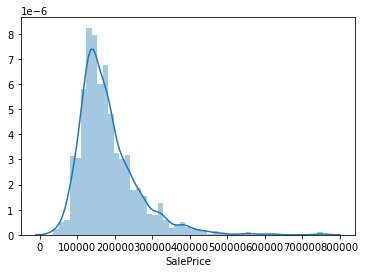

In [6]:
target = train['SalePrice']
sns.distplot(train['SalePrice']);

In [7]:
train['SalePrice'].value_counts()

140000    20
135000    17
145000    14
155000    14
190000    13
          ..
84900      1
424870     1
415298     1
62383      1
34900      1
Name: SalePrice, Length: 663, dtype: int64

Remove rows that occur only once

In [8]:
removals = train['SalePrice'].value_counts().reset_index()
removals = removals[removals['SalePrice'] > 1]['index'].values

filtered_train = train[train['SalePrice'].isin(removals)]
train = filtered_train
train


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1452,1453,180,RM,35.0,3675,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,TwnhsE,SLvl,5,5,2005,2005,Gable,CompShg,VinylSd,VinylSd,BrkFace,80.0,TA,TA,PConc,Gd,TA,Gd,GLQ,547,Unf,0,0,547,GasA,Gd,Y,SBrkr,1072,0,0,1072,1,0,1,0,2,1,TA,5,Typ,0,NaN,Basment,2005.0,Fin,2,525,TA,TA,Y,0,28,0,0,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal,145000
1453,1454,20,RL,90.0,17217,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,5,2006,2006,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,1140,1140,GasA,Ex,Y,SBrkr,1140,0,0,1140,0,0,1,0,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,Y,36,56,0,0,0,0,NaN,NaN,NaN,0,7,2006,WD,Abnorml,84500
1454,1455,20,FV,62.0,7500,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,7,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,None,0.0,Gd,TA,PConc,Gd,TA,No,GLQ,410,Unf,0,811,1221,GasA,Ex,Y,SBrkr,1221,0,0,1221,1,0,2,0,2,1,Gd,6,Typ,0,NaN,Attchd,2004.0,RFn,2,400,TA,TA,Y,0,113,0,0,0,0,NaN,NaN,NaN,0,10,2009,WD,Normal,185000
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,95

In [9]:
target.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Analyse target a second time

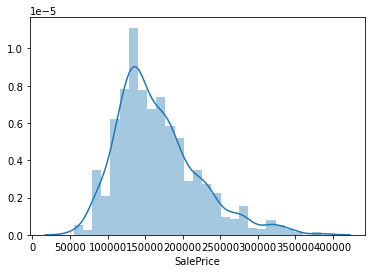

In [10]:
sns.distplot(train['SalePrice'], kde=True)

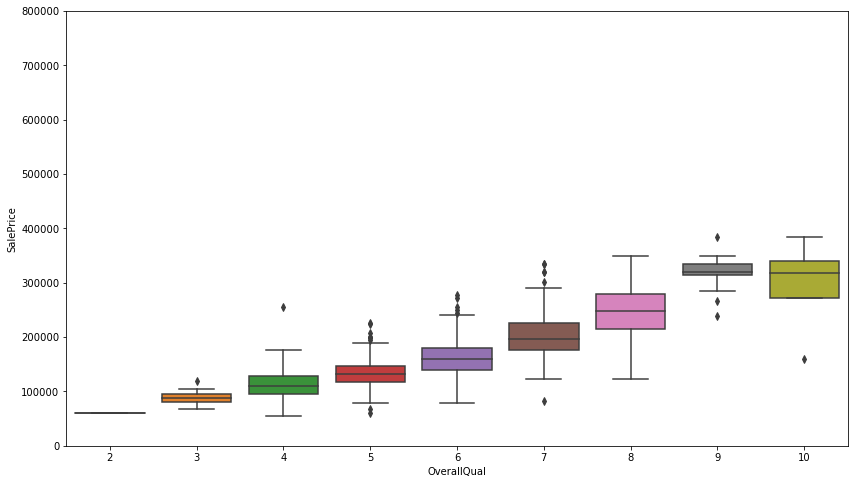

In [11]:
var = 'OverallQual'
data = pd.concat([train['SalePrice'], train[var]], axis=1)
f, ax = plt.subplots(figsize=(14, 8))
fig = sns.boxplot(x=var, y="SalePrice", data=data)
fig.axis(ymin=0, ymax=800000);

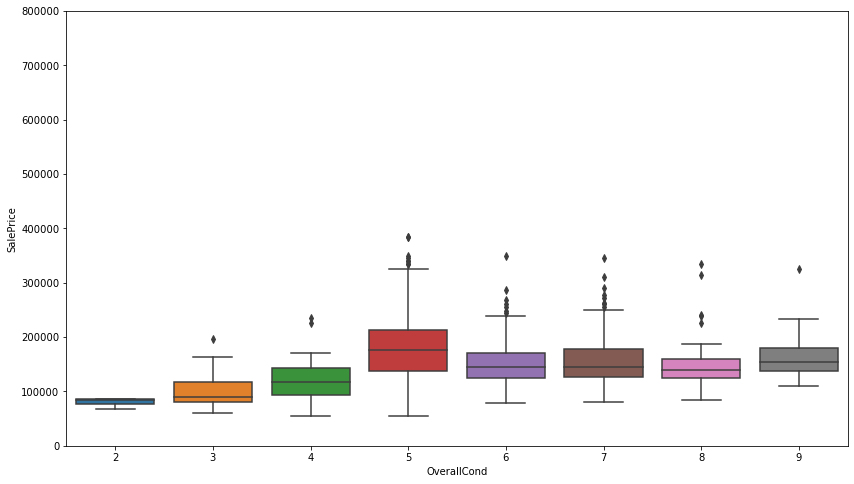

In [12]:
var = 'OverallCond'
data = pd.concat([train['SalePrice'], train[var]], axis=1)
f, ax = plt.subplots(figsize=(14, 8))
fig = sns.boxplot(x=var, y="SalePrice", data=data)
fig.axis(ymin=0, ymax=800000);

Check for null values on train

In [13]:
train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      200
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

Remove columns that have null values

In [14]:
train.columns[train.isnull().any()]

Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

Drop columns that have missing values

In [15]:
train.drop(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'], axis=1, inplace=True)

test.drop(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'], axis=1, inplace=True)


/opt/conda/lib/python3.7/site-packages/pandas/core/frame.py:4174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [16]:
train

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,ExterQual,ExterCond,Foundation,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageCars,GarageArea,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
2,3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,486,0,434,920,GasA,Ex,Y,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,2,608,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,TA,TA,BrkTil,216,0,540,756,GasA,Gd,Y,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,3,642,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,655,0,490,1145,GasA,Ex,Y,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,3,836,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000
5,6,50,RL,14115,Pave,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,TA,TA,Wood,732,0,64,796,GasA,Ex,Y,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,2,480,Y,40,30,0,320,0,0,700,10,2009,WD,Normal,143000
7,8,60,RL,10382,Pave,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,TA,TA,CBlock,859,32,216,1107,GasA,Ex,Y,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,2,484,Y,235,204,228,0,0,0,350,11,2009,WD,Normal,200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1452,1453,180,RM,3675,Pave,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,TwnhsE,SLvl,5,5,2005,2005,Gable,CompShg,VinylSd,VinylSd,TA,TA,PConc,547,0,0,547,GasA,Gd,Y,1072,0,0,1072,1,0,1,0,2,1,TA,5,Typ,0,2,525,Y,0,28,0,0,0,0,0,5,2006,WD,Normal,145000
1453,1454,20,RL,17217,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,5,2006,2006,Gable,CompShg,VinylSd,VinylSd,TA,TA,PConc,0,0,1140,1140,GasA,Ex,Y,1140,0,0,1140,0,0,1,0,3,1,TA,6,Typ,0,0,0,Y,36,56,0,0,0,0,0,7,2006,WD,Abnorml,84500
1454,1455,20,FV,7500,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,7,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,410,0,811,1221,GasA,Ex,Y,1221,0,0,1221,1,0,2,0,2,1,Gd,6,Typ,0,2,400,Y,0,113,0,0,0,0,0,10,2009,WD,Normal,185000
1455,1456,60,RL,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,TA,TA,PConc,0,0,953,953,GasA,Ex,Y,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,2,460,Y,0,40,0,0,0,0,0,8,2007,WD,Normal,175000


In [17]:
test

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,ExterQual,ExterCond,Foundation,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageCars,GarageArea,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,11622,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,TA,TA,CBlock,468.0,144.0,270.0,882.0,GasA,TA,Y,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,1.0,730.0,Y,140,0,0,0,120,0,0,6,2010,WD,Normal
1,1462,20,RL,14267,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,TA,TA,CBlock,923.0,0.0,406.0,1329.0,GasA,TA,Y,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,1.0,312.0,Y,393,36,0,0,0,0,12500,6,2010,WD,Normal
2,1463,60,RL,13830,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,TA,TA,PConc,791.0,0.0,137.0,928.0,GasA,Gd,Y,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,2.0,482.0,Y,212,34,0,0,0,0,0,3,2010,WD,Normal
3,1464,60,RL,9978,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,TA,TA,PConc,602.0,0.0,324.0,926.0,GasA,Ex,Y,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,2.0,470.0,Y,360,36,0,0,0,0,0,6,2010,WD,Normal
4,1465,120,RL,5005,Pave,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,Gd,TA,PConc,263.0,0.0,1017.0,1280.0,GasA,Ex,Y,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,2.0,506.0,Y,0,82,0,0,144,0,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,1936,Pave,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,TA,TA,CBlock,0.0,0.0,546.0,546.0,GasA,Gd,Y,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,0.0,0.0,Y,0,0,0,0,0,0,0,6,2006,WD,Normal
1455,2916,160,RM,1894,Pave,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,TA,TA,CBlock,252.0,0.0,294.0,546.0,GasA,TA,Y,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,1.0,286.0,Y,0,24,0,0,0,0,0,4,2006,WD,Abnorml
1456,2917,20,RL,20000,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,TA,TA,CBlock,1224.0,0.0,0.0,1224.0,GasA,Ex,Y,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,2.0,576.0,Y,474,0,0,0,0,0,0,9,2006,WD,Abnorml
1457,2918,85,RL,10441,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,TA,TA,PConc,337.0,0.0,575.0,912.0,GasA,TA,Y,970,0,0,970,0.0,1.0,1,0,3,1,TA,6,Typ,0,0.0,0.0,Y,80,32,0,0,0,0,700,7,2006,WD,Normal


Drop rows in train that have missing values

In [18]:
train = train.dropna()
train

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,ExterQual,ExterCond,Foundation,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageCars,GarageArea,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
2,3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,486,0,434,920,GasA,Ex,Y,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,2,608,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,TA,TA,BrkTil,216,0,540,756,GasA,Gd,Y,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,3,642,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,655,0,490,1145,GasA,Ex,Y,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,3,836,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000
5,6,50,RL,14115,Pave,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,TA,TA,Wood,732,0,64,796,GasA,Ex,Y,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,2,480,Y,40,30,0,320,0,0,700,10,2009,WD,Normal,143000
7,8,60,RL,10382,Pave,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,TA,TA,CBlock,859,32,216,1107,GasA,Ex,Y,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,2,484,Y,235,204,228,0,0,0,350,11,2009,WD,Normal,200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1452,1453,180,RM,3675,Pave,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,TwnhsE,SLvl,5,5,2005,2005,Gable,CompShg,VinylSd,VinylSd,TA,TA,PConc,547,0,0,547,GasA,Gd,Y,1072,0,0,1072,1,0,1,0,2,1,TA,5,Typ,0,2,525,Y,0,28,0,0,0,0,0,5,2006,WD,Normal,145000
1453,1454,20,RL,17217,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,5,2006,2006,Gable,CompShg,VinylSd,VinylSd,TA,TA,PConc,0,0,1140,1140,GasA,Ex,Y,1140,0,0,1140,0,0,1,0,3,1,TA,6,Typ,0,0,0,Y,36,56,0,0,0,0,0,7,2006,WD,Abnorml,84500
1454,1455,20,FV,7500,Pave,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,7,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,410,0,811,1221,GasA,Ex,Y,1221,0,0,1221,1,0,2,0,2,1,Gd,6,Typ,0,2,400,Y,0,113,0,0,0,0,0,10,2009,WD,Normal,185000
1455,1456,60,RL,7917,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,TA,TA,PConc,0,0,953,953,GasA,Ex,Y,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,2,460,Y,0,40,0,0,0,0,0,8,2007,WD,Normal,175000


Locate and delete outliers from train file

In [19]:
#for x in ['SalePrice']:
#    q75,q25 = np.percentile(train.loc[:,x],[75,25])
#    intr_qr = q75-q25
# 
#    max = q75+(1.5*intr_qr)
#    min = q25-(1.5*intr_qr)
# 
#    train.loc[train[x] < min,x] = np.nan
#    train.loc[train[x] > max,x] = np.nan

In [20]:
#train['SalePrice'].isnull().sum()

In [21]:
#train = train.dropna(axis = 0)
#train

Analyse SalePrice

In [22]:
#sns.distplot(train['SalePrice']);

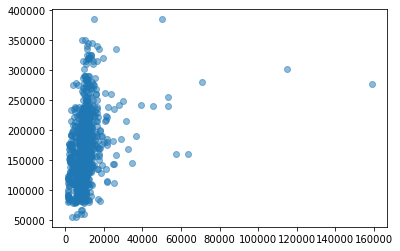

In [23]:
plt.scatter(train['LotArea'], train['SalePrice'], alpha=0.5, cmap='nipy_spectral')
plt.show()

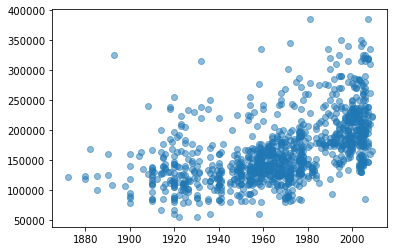

In [24]:
plt.scatter(train['YearBuilt'], train['SalePrice'], alpha=0.5, cmap='nipy_spectral')
plt.show()

Append train and test

In [25]:
train_copy = train
combi = train_copy.drop('SalePrice', axis =1)
combi = combi.append(test)
combi

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,ExterQual,ExterCond,Foundation,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageCars,GarageArea,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
2,3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,486.0,0.0,434.0,920.0,GasA,Ex,Y,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,2.0,608.0,Y,0,42,0,0,0,0,0,9,2008,WD,Normal
3,4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,TA,TA,BrkTil,216.0,0.0,540.0,756.0,GasA,Gd,Y,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,3.0,642.0,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml
4,5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,655.0,0.0,490.0,1145.0,GasA,Ex,Y,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,3.0,836.0,Y,192,84,0,0,0,0,0,12,2008,WD,Normal
5,6,50,RL,14115,Pave,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,TA,TA,Wood,732.0,0.0,64.0,796.0,GasA,Ex,Y,796,566,0,1362,1.0,0.0,1,1,1,1,TA,5,Typ,0,2.0,480.0,Y,40,30,0,320,0,0,700,10,2009,WD,Normal
7,8,60,RL,10382,Pave,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,TA,TA,CBlock,859.0,32.0,216.0,1107.0,GasA,Ex,Y,1107,983,0,2090,1.0,0.0,2,1,3,1,TA,7,Typ,2,2.0,484.0,Y,235,204,228,0,0,0,350,11,2009,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,1936,Pave,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,TA,TA,CBlock,0.0,0.0,546.0,546.0,GasA,Gd,Y,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,0.0,0.0,Y,0,0,0,0,0,0,0,6,2006,WD,Normal
1455,2916,160,RM,1894,Pave,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,TA,TA,CBlock,252.0,0.0,294.0,546.0,GasA,TA,Y,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,1.0,286.0,Y,0,24,0,0,0,0,0,4,2006,WD,Abnorml
1456,2917,20,RL,20000,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,TA,TA,CBlock,1224.0,0.0,0.0,1224.0,GasA,Ex,Y,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,2.0,576.0,Y,474,0,0,0,0,0,0,9,2006,WD,Abnorml
1457,2918,85,RL,10441,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,TA,TA,PConc,337.0,0.0,575.0,912.0,GasA,TA,Y,970,0,0,970,0.0,1.0,1,0,3,1,TA,6,Typ,0,0.0,0.0,Y,80,32,0,0,0,0,700,7,2006,WD,Normal


Drop Id

In [26]:
combi.drop(['Id'], axis=1, inplace=True)
combi

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,ExterQual,ExterCond,Foundation,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageCars,GarageArea,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
2,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,486.0,0.0,434.0,920.0,GasA,Ex,Y,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,2.0,608.0,Y,0,42,0,0,0,0,0,9,2008,WD,Normal
3,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,TA,TA,BrkTil,216.0,0.0,540.0,756.0,GasA,Gd,Y,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,3.0,642.0,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml
4,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,Gd,TA,PConc,655.0,0.0,490.0,1145.0,GasA,Ex,Y,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,3.0,836.0,Y,192,84,0,0,0,0,0,12,2008,WD,Normal
5,50,RL,14115,Pave,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,TA,TA,Wood,732.0,0.0,64.0,796.0,GasA,Ex,Y,796,566,0,1362,1.0,0.0,1,1,1,1,TA,5,Typ,0,2.0,480.0,Y,40,30,0,320,0,0,700,10,2009,WD,Normal
7,60,RL,10382,Pave,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,TA,TA,CBlock,859.0,32.0,216.0,1107.0,GasA,Ex,Y,1107,983,0,2090,1.0,0.0,2,1,3,1,TA,7,Typ,2,2.0,484.0,Y,235,204,228,0,0,0,350,11,2009,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,RM,1936,Pave,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,TA,TA,CBlock,0.0,0.0,546.0,546.0,GasA,Gd,Y,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,0.0,0.0,Y,0,0,0,0,0,0,0,6,2006,WD,Normal
1455,160,RM,1894,Pave,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,TA,TA,CBlock,252.0,0.0,294.0,546.0,GasA,TA,Y,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,1.0,286.0,Y,0,24,0,0,0,0,0,4,2006,WD,Abnorml
1456,20,RL,20000,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,TA,TA,CBlock,1224.0,0.0,0.0,1224.0,GasA,Ex,Y,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,2.0,576.0,Y,474,0,0,0,0,0,0,9,2006,WD,Abnorml
1457,85,RL,10441,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,TA,TA,PConc,337.0,0.0,575.0,912.0,GasA,TA,Y,970,0,0,970,0.0,1.0,1,0,3,1,TA,6,Typ,0,0.0,0.0,Y,80,32,0,0,0,0,700,7,2006,WD,Normal


Check null values

In [27]:
combi.columns[combi.isnull().any()]

Index(['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
       'BsmtHalfBath', 'KitchenQual', 'Functional', 'GarageCars', 'GarageArea',
       'SaleType'],
      dtype='object')

In [28]:
combi.drop(['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
       'BsmtHalfBath', 'KitchenQual', 'Functional', 'GarageCars', 'GarageArea',
       'SaleType'], axis=1, inplace=True)

In [29]:
combi.isnull().sum().sum()

0

Encode

In [30]:
from sklearn import preprocessing
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder()

for col in combi:
    if combi[col].dtype=="object":
        combi[col] = enc.fit_transform(combi[col].values.reshape(-1,1))
combi

,MSSubClass,LotArea,Street,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,ExterQual,ExterCond,Foundation,Heating,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleCondition
2,60,11250,1.0,0.0,3.0,4.0,0.0,5.0,2.0,2.0,0.0,5.0,7,5,2001,2002,1.0,1.0,2.0,4.0,2.0,0.0,0.0,1.0,920,866,0,1786,2,1,3,1,6,1,2.0,0,42,0,0,0,0,0,9,2008,4.0
3,70,9550,1.0,0.0,3.0,0.0,0.0,6.0,2.0,2.0,0.0,5.0,7,5,1915,1970,1.0,1.0,3.0,4.0,0.0,0.0,2.0,1.0,961,756,0,1717,1,0,3,1,7,1,2.0,0,35,272,0,0,0,0,2,2006,0.0
4,60,14260,1.0,0.0,3.0,2.0,0.0,15.0,2.0,2.0,0.0,5.0,8,5,2000,2000,1.0,1.0,2.0,4.0,2.0,0.0,0.0,1.0,1145,1053,0,2198,2,1,4,1,9,1,2.0,192,84,0,0,0,0,0,12,2008,4.0
5,50,14115,1.0,0.0,3.0,4.0,0.0,11.0,2.0,2.0,0.0,0.0,5,5,1993,1995,1.0,1.0,3.0,4.0,5.0,0.0,0.0,1.0,796,566,0,1362,1,1,1,1,5,0,2.0,40,30,0,320,0,0,700,10,2009,4.0
7,60,10382,1.0,0.0,3.0,0.0,0.0,14.0,4.0,2.0,0.0,5.0,7,6,1973,1973,1.0,1.0,3.0,4.0,1.0,0.0,0.0,1.0,1107,983,0,2090,2,1,3,1,7,2,2.0,235,204,228,0,0,0,350,11,2009,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,1936,1.0,3.0,3.0,4.0,0.0,10.0,2.0,2.0,3.0,5.0,4,7,1970,1970,1.0,1.0,3.0,4.0,1.0,0.0,2.0,1.0,546,546,0,1092,1,1,3,1,5,0,2.0,0,0,0,0,0,0,0,6,2006,4.0
1455,160,1894,1.0,3.0,3.0,4.0,0.0,10.0,2.0,2.0,4.0,5.0,4,5,1970,1970,1.0,1.0,3.0,4.0,1.0,0.0,4.0,1.0,546,546,0,1092,1,1,3,1,6,0,2.0,0,24,0,0,0,0,0,4,2006,0.0
1456,20,20000,1.0,3.0,3.0,4.0,0.0,11.0,2.0,2.0,0.0,2.0,5,7,1960,1996,1.0,1.0,3.0,4.0,1.0,0.0,0.0,1.0,1224,0,0,1224,1,0,4,1,7,1,2.0,474,0,0,0,0,0,0,9,2006,0.0
1457,85,10441,1.0,3.0,3.0,4.0,0.0,11.0,2.0,2.0,0.0,6.0,5,5,1992,1992,1.0,1.0,3.0,4.0,2.0,0.0,4.0,1.0,970,0,0,970,1,0,3,1,6,0,2.0,80,32,0,0,0,0,700,7,2006,4.0


Heatmap

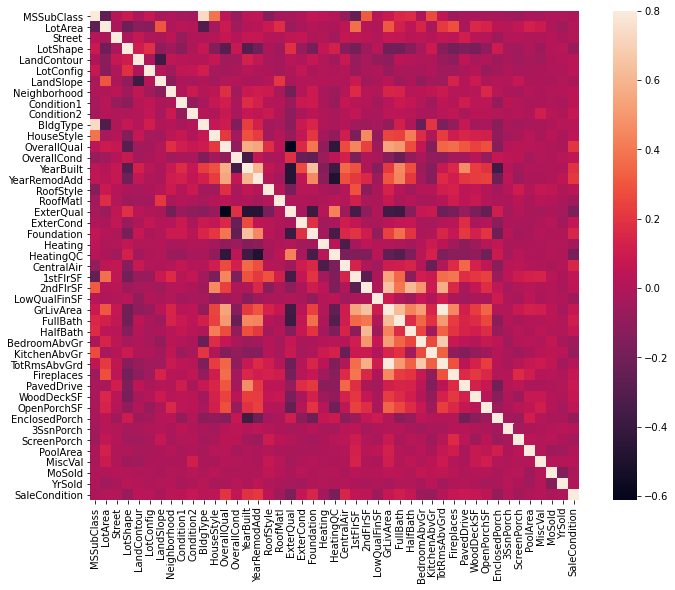

In [31]:
corr = combi.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, vmax=.8, square=True);

In [32]:
corr

,MSSubClass,LotArea,Street,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,ExterQual,ExterCond,Foundation,Heating,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleCondition
MSSubClass,1.000000,-0.268953,0.012421,0.086100,-0.008115,0.073321,-0.032481,-0.000298,-0.029468,-0.040911,0.736031,0.384684,0.043139,-0.075064,0.040234,0.051007,-0.128891,-0.034449,-0.028940,0.000089,0.058359,0.043794,0.017924,-0.089160,-0.242234,0.312810,0.022914,0.083261,0.154586,0.166585,-0.005507,0.268085,0.051409,-0.059200,-0.022399,-0.026300,-0.019168,-0.021301,-0.042010,-0.052868,-0.009763,-0.026570,0.002484,-0.005189,-0.007573
LotArea,-0.268953,1.000000,-0.021792,-0.213406,-0.124379,-0.130237,0.298600,0.000471,0.032988,0.018734,-0.318776,-0.031111,0.091182,-0.044806,0.016077,0.031214,0.083903,0.176154,-0.065419,-0.012278,0.019084,0.005307,-0.010151,0.046665,0.373207,0.017631,0.001021,0.309083,0.116449,0.041504,0.142535,-0.025703,0.220411,0.276118,-0.013385,0.153804,0.135724,0.035797,0.025147,0.057927,0.124592,0.092134,0.001169,-0.048117,0.007830
Street,0.012421,-0.021792,1.000000,-0.020045,0.077050,-0.001951,-0.014700,0.037647,-0.079624,-0.000700,0.003203,0.014459,0.074745,0.013774,0.068136,0.074242,0.011515,0.007287,0.052641,0.060646,0.002291,0.006200,-0.035967,0.064508,0.054500,0.034702,0.005959,0.073601,0.059993,0.031265,0.047038,0.012450,0.050406,0.043780,0.113943,0.031822,0.019959,-0.054599,0.006464,0.017448,0.003734,-0.001555,0.021478,-0.014541,0.011171
LotShape,0.086100,-0.213406,-0.020045,1.000000,0.102520,0.183382,-0.096105,-0.049645,-0.121047,0.003135,0.072337,-0.146951,-0.284005,0.080588,-0.299926,-0.198343,-0.010640,-0.056790,0.182292,-0.067456,-0.182552,0.060555,0.126295,-0.129207,-0.195277,-0.054834,0.027906,-0.198566,-0.202591,-0.128104,-0.028300,0.092721,-0.127409,-0.195553,-0.160188,-0.180059,-0.098462,0.094553,-0.029704,-0.048463,0.002400,-0.053114,0.012214,0.024674,-0.071546
LandContour,-0.008115,-0.124379,0.077050,0.102520,1.000000,-0.006717,-0.377587,0.052685,0.025936,0.016496,0.015107,0.067487,-0.046195,-0.033911,0.126172,0.060389,-0.025242,-0.040023,0.032851,-0.001610,0.071075,0.007115,-0.036083,0.078142,-0.080670,-0.032258,-0.091072,-0.100347,0.036917,0.020180,-0.000144,-0.003800,-0.072195,-0.100139,0.044407,-0.023994,-0.004878,-0.058482,-0.016777,-0.045971,-0.031134,-0.045158,-0.001040,0.013300,0.029435
LotConfig,0.073321,-0.130237,-0.001951,0.183382,-0.006717,1.000000,0.014694,-0.049343,0.052978,0.058648,0.110590,-0.031256,-0.035502,-0.018072,0.023915,0.004626,-0.010080,-0.039176,-0.000982,0.056748,-0.008695,0.006033,-0.000836,0.008769,-0.070940,-0.019340,0.002744,-0.072350,-0.015831,-0.025836,-0.026945,-0.003043,-0.045320,-0.049329,-0.013822,0.012351,-0.072942,-0.037612,-0.003675,-0.022079,-0.021190,-0.009301,0.002582,0.001615,0.028442
LandSlope,-0.032481,0.298600,-0.014700,-0.096105,-0.377587,0.014694,1.000000,-0.112514,-0.006547,-0.026440,-0.002920,-0.033935,0.008197,0.012315,-0.010302,-0.015503,0.020068,0.207054,-0.017954,0.012540,0.006934,0.021328,0.008571,-0.002708,0.086649,-0.044495,-0.007729,0.028793,-0.057231,-0.010661,-0.088850,-0.036788,-0.044783,0.136462,0.015517,0.091864,0.000721,0.017256,0.012372,0.068508,-0.006295,-0.006078,-0.014088,0.011066,-0.020132
Neighborhood,-0.000298,0.000471,0.037647,-0.049645,0.052685,-0.049343,-0.112514,1.000000,0.000654,0.084292,0.021009,0.045679,0.181825,-0.044237,0.087390,0.101637,0.089369,-0.018592,-0.188918,0.015712,0.090643,-0.023493,-0.064157,0.021602,0.160860,0.016252,0.010796,0.141742,0.135968,0.025846,0.034768,0.054325,0.084093,0.022565,0.017140,0.025066,0.150429,0.025436,-0.009702,-0.010809,0.018713,-0.007383,0.008282,0.013807,0.034770
Condition1,-0.029468,0.032988,-0.079624,

Remove columns that have a high correlation

In [33]:
columns = np.full((corr.shape[0],), True, dtype=bool)
for i in range(corr.shape[0]):
    for j in range(i+1, corr.shape[0]):
        if corr.iloc[i,j] >= 0.9:
            if columns[j]:
                columns[j] = False
selected_columns = combi.columns[columns]
combi = combi[selected_columns]
combi

,MSSubClass,LotArea,Street,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,ExterQual,ExterCond,Foundation,Heating,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleCondition
2,60,11250,1.0,0.0,3.0,4.0,0.0,5.0,2.0,2.0,0.0,5.0,7,5,2001,2002,1.0,1.0,2.0,4.0,2.0,0.0,0.0,1.0,920,866,0,1786,2,1,3,1,6,1,2.0,0,42,0,0,0,0,0,9,2008,4.0
3,70,9550,1.0,0.0,3.0,0.0,0.0,6.0,2.0,2.0,0.0,5.0,7,5,1915,1970,1.0,1.0,3.0,4.0,0.0,0.0,2.0,1.0,961,756,0,1717,1,0,3,1,7,1,2.0,0,35,272,0,0,0,0,2,2006,0.0
4,60,14260,1.0,0.0,3.0,2.0,0.0,15.0,2.0,2.0,0.0,5.0,8,5,2000,2000,1.0,1.0,2.0,4.0,2.0,0.0,0.0,1.0,1145,1053,0,2198,2,1,4,1,9,1,2.0,192,84,0,0,0,0,0,12,2008,4.0
5,50,14115,1.0,0.0,3.0,4.0,0.0,11.0,2.0,2.0,0.0,0.0,5,5,1993,1995,1.0,1.0,3.0,4.0,5.0,0.0,0.0,1.0,796,566,0,1362,1,1,1,1,5,0,2.0,40,30,0,320,0,0,700,10,2009,4.0
7,60,10382,1.0,0.0,3.0,0.0,0.0,14.0,4.0,2.0,0.0,5.0,7,6,1973,1973,1.0,1.0,3.0,4.0,1.0,0.0,0.0,1.0,1107,983,0,2090,2,1,3,1,7,2,2.0,235,204,228,0,0,0,350,11,2009,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,1936,1.0,3.0,3.0,4.0,0.0,10.0,2.0,2.0,3.0,5.0,4,7,1970,1970,1.0,1.0,3.0,4.0,1.0,0.0,2.0,1.0,546,546,0,1092,1,1,3,1,5,0,2.0,0,0,0,0,0,0,0,6,2006,4.0
1455,160,1894,1.0,3.0,3.0,4.0,0.0,10.0,2.0,2.0,4.0,5.0,4,5,1970,1970,1.0,1.0,3.0,4.0,1.0,0.0,4.0,1.0,546,546,0,1092,1,1,3,1,6,0,2.0,0,24,0,0,0,0,0,4,2006,0.0
1456,20,20000,1.0,3.0,3.0,4.0,0.0,11.0,2.0,2.0,0.0,2.0,5,7,1960,1996,1.0,1.0,3.0,4.0,1.0,0.0,0.0,1.0,1224,0,0,1224,1,0,4,1,7,1,2.0,474,0,0,0,0,0,0,9,2006,0.0
1457,85,10441,1.0,3.0,3.0,4.0,0.0,11.0,2.0,2.0,0.0,6.0,5,5,1992,1992,1.0,1.0,3.0,4.0,2.0,0.0,4.0,1.0,970,0,0,970,1,0,3,1,6,0,2.0,80,32,0,0,0,0,700,7,2006,4.0


Normalise

In [34]:
combi = (combi - combi.min()) / (combi.max() - combi.min())
combi

,MSSubClass,LotArea,Street,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,ExterQual,ExterCond,Foundation,Heating,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleCondition
2,0.235294,0.063094,1.0,0.0,1.0,1.0,0.0,0.208333,0.25,0.333333,0.00,0.714286,0.666667,0.500,0.934783,0.866667,0.2,0.142857,0.666667,1.0,0.4,0.0,0.0,1.0,0.116028,0.465091,0.0,0.263419,0.50,0.5,0.375,0.333333,0.250000,0.25,1.0,0.000000,0.056604,0.000000,0.000000,0.0,0.0,0.000000,0.727273,0.50,0.8
3,0.294118,0.052315,1.0,0.0,1.0,0.0,0.0,0.250000,0.25,0.333333,0.00,0.714286,0.666667,0.500,0.311594,0.333333,0.2,0.142857,1.000000,1.0,0.0,0.0,0.5,1.0,0.124709,0.406015,0.0,0.250239,0.25,0.0,0.375,0.333333,0.333333,0.25,1.0,0.000000,0.047170,0.268775,0.000000,0.0,0.0,0.000000,0.090909,0.00,0.0
4,0.235294,0.082181,1.0,0.0,1.0,0.5,0.0,0.625000,0.25,0.333333,0.00,0.714286,0.777778,0.500,0.927536,0.833333,0.2,0.142857,0.666667,1.0,0.4,0.0,0.0,1.0,0.163667,0.565521,0.0,0.342120,0.50,0.5,0.500,0.333333,0.500000,0.25,1.0,0.134831,0.113208,0.000000,0.000000,0.0,0.0,0.000000,1.000000,0.50,0.8
5,0.176471,0.081262,1.0,0.0,1.0,1.0,0.0,0.458333,0.25,0.333333,0.00,0.000000,0.444444,0.500,0.876812,0.750000,0.2,0.142857,1.000000,1.0,1.0,0.0,0.0,1.0,0.089773,0.303974,0.0,0.182426,0.25,0.5,0.125,0.333333,0.166667,0.00,1.0,0.028090,0.040431,0.000000,0.629921,0.0,0.0,0.041176,0.818182,0.75,0.8
7,0.235294,0.057590,1.0,0.0,1.0,0.0,0.0,0.583333,0.50,0.333333,0.00,0.714286,0.666667,0.625,0.731884,0.383333,0.2,0.142857,1.000000,1.0,0.2,0.0,0.0,1.0,0.155621,0.527927,0.0,0.321490,0.50,0.5,0.375,0.333333,0.333333,0.50,1.0,0.165028,0.274933,0.225296,0.000000,0.0,0.0,0.020588,0.909091,0.75,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,0.823529,0.004033,1.0,1.0,1.0,1.0,0.0,0.416667,0.25,0.333333,0.75,0.714286,0.333333,0.750,0.710145,0.333333,0.2,0.142857,1.000000,1.0,0.2,0.0,0.5,1.0,0.036841,0.293233,0.0,0.130850,0.25,0.5,0.375,0.333333,0.166667,0.00,1.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.454545,0.00,0.8
1455,0.823529,0.003767,1.0,1.0,1.0,1.0,0.0,0.416667,0.25,0.333333,1.00,0.714286,0.333333,0.500,0.710145,0.333333,0.2,0.142857,1.000000,1.0,0.2,0.0,1.0,1.0,0.036841,0.293233,0.0,0.130850,0.25,0.5,0.375,0.333333,0.250000,0.00,1.0,0.000000,0.032345,0.000000,0.000000,0.0,0.0,0.000000,0.272727,0.00,0.0
1456,0.000000,0.118580,1.0,1.0,1.0,1.0,0.0,0.458333,0.25,0.333333,0.00,0.285714,0.444444,0.750,0.637681,0.766667,0.2,0.142857,1.000000,1.0,0.2,0.0,0.0,1.0,0.180394,0.000000,0.0,0.156065,0.25,0.0,0.500,0.333333,0.333333,0.25,1.0,0.332865,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.727273,0.00,0.0
1457,0.382353,0.057964,1.0,1.0,1.0,1.0,0.0,0.458333,0.25,0.333333,0.00,0.857143,0.444444,0.500,0.869565,0.700000,0.2,0.142857,1.000000,1.0,0.4,0.0,1.0,1.0,0.126614,0.000000,0.0,0.107545,0.25,0.0,0.375,0.333333,0.250000,0.00,1.0,0.056180,0.043127,0.000000,0.000000,0.0,0.0,0.041176,0.545455,0.00,0.8


Define X and y

In [35]:
y = train['SalePrice']
X = combi[: len(train)]
X_test = combi[len(train) :]

Split X_Train for training and validation

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)
X_train.shape, X_val.shape, y_train.shape,y_val.shape, X_test.shape

((947, 45), (106, 45), (947,), (106,), (1459, 45))

Select model - Linear Regression

In [37]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression().fit(X_train, y_train)
print(model1.score(X_train, y_train))

0.8064159412780758


Predict on validation set

In [38]:
y_pred1 = model1.predict(X_val)
print(model1.score(X_val, y_val))

0.8689094760861658


In [39]:
from sklearn.metrics import mean_squared_error

rmse = mean_squared_error(y_val, y_pred1, squared=False)
rmse

21965.371737471523

In [40]:
df=pd.DataFrame({'Actual': y_val, 'Predicted':y_pred1})
df

,Actual,Predicted
553,108000,110746.426454
133,220000,215902.316501
1348,215000,224060.236237
1456,210000,216778.018425
84,168500,185870.637328
...,...,...
138,230000,247182.786708
877,350000,263470.682915
1203,213000,219277.876099
111,180000,189879.251348


Graphics

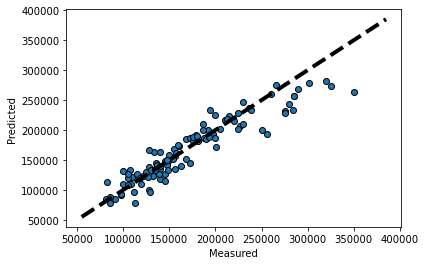

In [41]:
fig, ax = plt.subplots()
ax.scatter(y_val, y_pred1, edgecolors=(0, 0, 0))
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Measured')
ax.set_ylabel('Predicted')
plt.show()

KNN

In [42]:
from sklearn.neighbors import KNeighborsRegressor

model2 = KNeighborsRegressor(algorithm='auto', n_neighbors=7,p=1, weights='distance').fit(X_train, y_train)
print(model2.score(X_train, y_train))

1.0


Predict on validation

In [43]:
y_pred2 = model2.predict(X_val)
print(model2.score(X_val, y_val))

0.6764617613517929


Metrics

In [44]:
from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(y_val, y_pred2))
print('Mean Squared Error:', metrics.mean_squared_error(y_val, y_pred2))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_val, y_pred2)))

Mean Absolute Error: 23384.02231707819
Mean Squared Error: 1190779728.8040297
Root Mean Squared Error: 34507.676375033276


Compare

In [45]:
compare = pd.DataFrame({'actual': y_val.values.ravel(), 'predicted': y_pred2})
compare

,actual,predicted
0,108000,128353.612087
1,220000,213108.634874
2,215000,205574.148524
3,210000,159128.609885
4,168500,176129.310898
...,...,...
101,230000,225720.127089
102,350000,246481.028728
103,213000,205523.697311
104,180000,183573.717655


Plot predictions

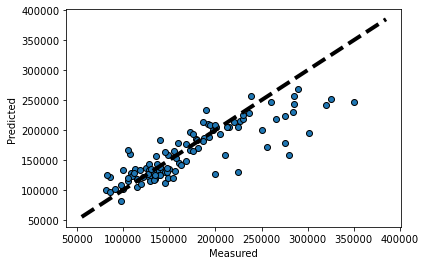

In [46]:
fig, ax = plt.subplots()
ax.scatter(y_val, y_pred2, edgecolors=(0, 0, 0))
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Measured')
ax.set_ylabel('Predicted')
plt.show()

Extra Trees

In [47]:
from sklearn.ensemble import ExtraTreesRegressor

model3 = ExtraTreesRegressor(ccp_alpha=0, criterion='mse', max_features='auto', n_estimators=500, random_state=42).fit(X_train, y_train)
print(model3.score(X_train, y_train))

1.0


Predict on validation set

In [48]:
y_pred3 = model3.predict(X_val)
print(model3.score(X_val, y_val))

0.8720571870850846


Metrics

In [49]:
from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(y_val, y_pred3))
print('Mean Squared Error:', metrics.mean_squared_error(y_val, y_pred3))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_val, y_pred3)))

Mean Absolute Error: 15530.637735849057
Mean Squared Error: 470892432.0716982
Root Mean Squared Error: 21700.056038446033


Compare

In [50]:
compare = pd.DataFrame({'actual': y_val.values.ravel(), 'predicted': y_pred3})
compare

,actual,predicted
0,108000,127231.4
1,220000,196239.8
2,215000,229203.2
3,210000,196312.2
4,168500,175340.2
...,...,...
101,230000,239620.0
102,350000,304305.0
103,213000,220203.0
104,180000,173516.0


Plot predictions

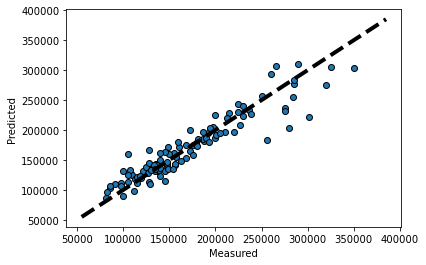

In [51]:
fig, ax = plt.subplots()
ax.scatter(y_val, y_pred3, edgecolors=(0, 0, 0))
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Measured')
ax.set_ylabel('Predicted')
plt.show()

Voting Regressor

In [52]:
from sklearn.ensemble import VotingRegressor

emodel1 = VotingRegressor(estimators=[('LR', model1), ('KNN', model2), ('ET', model3)]).fit(X_train, y_train)
print(emodel1.score(X_train, y_train))

0.9784906601420085


Predict on validation set

In [53]:
y_pred4 = emodel1.predict(X_val)
print(emodel1.score(X_val, y_val))

0.8524092817527298


Metrics

In [54]:
from sklearn import metrics

print('Mean Absolute Error:', metrics.mean_absolute_error(y_val, y_pred4))
print('Mean Squared Error:', metrics.mean_squared_error(y_val, y_pred4))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_val, y_pred4)))

Mean Absolute Error: 15846.508353031099
Mean Squared Error: 543206380.1261296
Root Mean Squared Error: 23306.78828423448


Compare

In [55]:
compare = pd.DataFrame({'actual': y_val.values.ravel(), 'predicted': y_pred4})
compare

,actual,predicted
0,108000,122110.479514
1,220000,208416.917125
2,215000,219612.528254
3,210000,190739.609437
4,168500,179113.382742
...,...,...
101,230000,237507.637933
102,350000,271418.903881
103,213000,215001.524470
104,180000,182322.989668


Plot graph

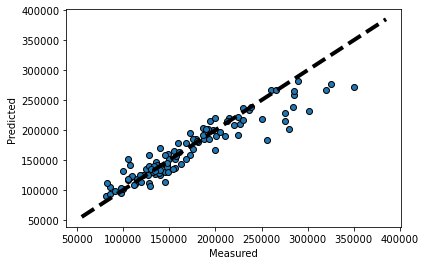

In [56]:
fig, ax = plt.subplots()
ax.scatter(y_val, y_pred4, edgecolors=(0, 0, 0))
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Measured')
ax.set_ylabel('Predicted')
plt.show()

Predict on test set and submit

In [57]:
preds = emodel1.predict(X_test)
preds = preds.astype(int)
preds[preds < 0] = 0
preds

array([127178, 143472, 175917, ..., 145024, 129622, 226003])

Submit

In [58]:
submission.SalePrice = preds
submission.to_csv('submission.csv', index=False)
submission = pd.read_csv("submission.csv")
submission

,Id,SalePrice
0,1461,127178
1,1462,143472
2,1463,175917
3,1464,190025
4,1465,198171
...,...,...
1454,2915,101093
1455,2916,91634
1456,2917,145024
1457,2918,129622
